In [2]:
import os
from dotenv import load_dotenv

from typing import TypedDict

from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings

from langchain_community.document_loaders import PyPDFLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter

from langchain_chroma import Chroma

from langgraph.graph import StateGraph, START, END

load_dotenv()

True

##### Load PDF

In [3]:
loader = PyPDFLoader("docs/Autonomous Data Science Agent.pdf")
docs = loader.load()

##### Chunk Documents

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200
)

chunks = splitter.split_documents(docs)

print(f"Created {len(chunks)} chunks")

Created 133 chunks


##### Embedding

In [6]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

d:\RAG\rag_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2525.01it/s]


##### Vector Store

In [7]:
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embedding_model,
    persist_directory="./chroma_db"
)

Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


##### Retriever

In [8]:
retriever = vectorstore.as_retriever(
    search_kwargs={"k": 4}
)

##### LLM

In [9]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

##### Graph State

In [10]:
class GraphState(TypedDict):
    query: str
    complexity: str
    answer: str
    intermediate_answer: str

##### Complexity Classifier

In [11]:
def classify_query(state):

    query = state["query"]

    prompt = f"""
You are a query complexity classifier.

Classify into:

simple = general knowledge

medium = needs document retrieval

complex = multi-hop reasoning requiring multiple retrieval steps

Question:
{query}

Return ONLY:
simple
or
medium
or
complex
"""

    response = llm.invoke(prompt)

    return {
        "complexity": response.content.strip().lower()
    }

##### Simple Route

In [12]:
def simple_route(state):

    response = llm.invoke(
        state["query"]
    )

    return {
        "answer": response.content
    }

##### Medium Route (Single Retrieval)

In [13]:
def medium_route(state):

    docs = retriever.invoke(
        state["query"]
    )

    context = "\n\n".join(
        doc.page_content
        for doc in docs
    )

    prompt = f"""
Answer using the context.

Context:
{context}

Question:
{state['query']}
"""

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

##### Complex Route (Iterative Retrieval)

In [14]:
def complex_route(state):

    query = state["query"]

    # First Retrieval
    docs1 = retriever.invoke(query)

    context1 = "\n\n".join(
        doc.page_content
        for doc in docs1
    )

    reasoning_prompt = f"""
Question:
{query}

Context:
{context1}

Generate an intermediate reasoning step
to help answer the question.
"""

    intermediate = llm.invoke(
        reasoning_prompt
    ).content

    # Second Retrieval
    docs2 = retriever.invoke(
        intermediate
    )

    context2 = "\n\n".join(
        doc.page_content
        for doc in docs2
    )

    final_prompt = f"""
Answer the question.

Question:
{query}

Context 1:
{context1}

Context 2:
{context2}

Intermediate Reasoning:
{intermediate}
"""

    final_answer = llm.invoke(
        final_prompt
    )

    return {
        "intermediate_answer": intermediate,
        "answer": final_answer.content
    }

##### Router

In [15]:
def route_query(state):

    return state["complexity"]

##### Build Graph

In [16]:
builder = StateGraph(GraphState)

builder.add_node(
    "classifier",
    classify_query
)

builder.add_node(
    "simple",
    simple_route
)

builder.add_node(
    "medium",
    medium_route
)

builder.add_node(
    "complex",
    complex_route
)

builder.add_edge(
    START,
    "classifier"
)

builder.add_conditional_edges(
    "classifier",
    route_query,
    {
        "simple": "simple",
        "medium": "medium",
        "complex": "complex"
    }
)

builder.add_edge("simple", END)
builder.add_edge("medium", END)
builder.add_edge("complex", END)

graph = builder.compile()

##### Visualize Graph

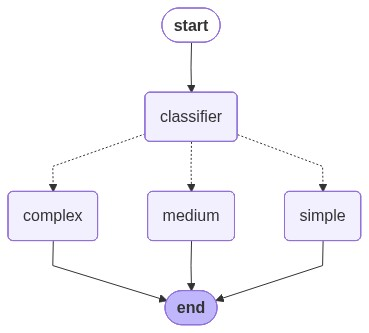

In [17]:
from IPython.display import Image
from IPython.display import display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [23]:
result = graph.invoke(
    {
        "query": "Explain  Agentic Optimization for EvoD"
    }
)

print(result["complexity"])
print()
print(result["answer"])

complex

To further explain Agentic Optimization for EvoD, let's delve into the key components and processes involved.

**Agentic Optimization Process**:

The Agentic Optimization process in EvoDS involves the following steps:

1. **Initialization**: The Manager Agent and sub-agents are initialized with their respective scoring functions and localized contexts.
2. **Exploration**: The Manager Agent selects a sub-agent based on its scoring function, and the sub-agent explores the environment to gather information and learn about the task.
3. **Exploitation**: The sub-agent uses its learned knowledge to select the best tool or action to achieve the task goal.
4. **Feedback**: The environment provides feedback to the sub-agent in the form of rewards or penalties, which are used to update the sub-agent's scoring function.
5. **Optimization**: The Manager Agent uses the updated scoring functions to optimize the selection of sub-agents and tools, and the sub-agents use the feedback to optimi

In [24]:
result = graph.invoke(
    {
        "query": "Full stack AI development"
    }
)

print(result["complexity"])
print()
print(result["answer"])

complex

Full stack AI development refers to the process of building, deploying, and maintaining artificial intelligence (AI) systems that can perform a wide range of tasks, from data processing and analysis to decision-making and execution. 

To achieve this, several key components are required, including:

1. **Data Collection and Preprocessing**: The ability to gather, process, and prepare data for analysis and model training.
2. **Model Training and Deployment**: The capacity to train, deploy, and manage AI models, including neural networks, decision trees, and other machine learning algorithms.
3. **LLM Integration**: The incorporation of large language models (LLMs) to enable natural language understanding, generation, and interaction.
4. **Feedback Mechanisms**: The implementation of feedback loops to allow the system to learn from experience, adapt to new situations, and improve over time.
5. **Multi-Agent Architecture**: The design of a multi-agent system that can integrate mu